# Sensor Sequence Explorer

Interactive panels over the raw CMI data. All logic lives in
`sequence_explorer_utils.py` — this notebook only wires it up.

| Tab | What it does |
|---|---|
| **Sequence** | Shared filters + dropdown (or paste `sequence_id`); **Add current** builds a catalog; overlay or grid view |
| **Features** | Before/after one sequence via `SequenceExtractor._preprocess_features` with full parameter exposure |
| **Spectrum** | Hann rFFT / Welch PSD / spectrogram on raw vs pipeline output (raw→velocity→displacement→jerk) |
| **Clusters** | Frame features → scale → PCA/t-SNE/UMAP → KMeans/GMM/Agglomerative/DBSCAN/HDBSCAN |

The filter row at the top is shared: it drives the sequence dropdown, the catalog,
and (optionally) cluster population. Use **Source** on the Clusters tab to cluster
filtered rows, catalog IDs, or the union of both.

In [7]:
import os
import sys
import warnings

import pandas as pd

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
%matplotlib inline

current_dir = os.getcwd()
workspace_root = os.path.dirname(current_dir) if os.path.basename(current_dir) == 'notebooks' else current_dir
sys.path.insert(0, workspace_root)
sys.path.insert(0, os.path.join(workspace_root, 'src'))

try:
    dataset_name = os.listdir('/kaggle/input/datasets/keithmarange')[0]
    sys.path.append(f'/kaggle/input/datasets/keithmarange/{dataset_name}/')
    sys.path.append(f'/kaggle/input/datasets/keithmarange/{dataset_name}/src')
    sys.path.append('/kaggle/input/cmi-competition-code')
except Exception:
    pass

try:
    from src import data_utils
    from src.sequence_explorer_utils import SequenceExplorer
except ImportError:
    import data_utils
    from sequence_explorer_utils import SequenceExplorer

print('Workspace root:', workspace_root)

Workspace root: c:\Users\maran\OneDrive\Documents\Git Profile\cmi_dexter


## 1. Configuration

In [8]:
use_sample_data = True          # True -> data/sample.csv, False -> data/train.csv
sample_file = 'sample.csv'
label_col = 'gesture'          # used for the true-label panel and cluster purity
sampling_rate_hz = 20.0        # IMU native rate; drives every frequency axis
random_state = 42

## 2. Load

In [9]:
data_root = data_utils.find_data_root()
sample_path = data_root / sample_file

if use_sample_data and sample_path.exists():
    raw_df = pd.read_csv(sample_path)
    print(f'Using {sample_file}: {raw_df["sequence_id"].nunique()} sequences')
else:
    raw_df = pd.read_csv(data_root / 'train.csv')
    print(f'Using train.csv: {raw_df["sequence_id"].nunique()} sequences')

df = raw_df.set_index('row_id').copy(deep=True)
df['gesture'] = df['gesture'].fillna('non_bfrb').astype(str)
df['orientation'] = df['orientation'].fillna('Unknown').astype(str)
df['is_target'] = df['sequence_type'].eq('Target').astype(int)
df['bfrb'] = df['gesture'].where(df['is_target'].astype(bool), 'non_bfrb')

print(f'{df.shape[0]:,} rows | {df["sequence_id"].nunique():,} sequences | '
      f'{df["subject"].nunique()} subjects')

✅ Found data folder: C:\Users\maran\OneDrive\Documents\Git Profile\cmi_dexter\data
Using sample.csv: 37 sequences
2,679 rows | 37 sequences | 31 subjects


## 3. Explore

Every panel re-runs on any control change. On full `train.csv` keep **Max seqs**
low (≤400) for the Clusters tab — the extractor runs over every selected
sequence on each change.

In [ ]:
explorer = SequenceExplorer(
    df,
    label_col=label_col,
    fs=sampling_rate_hz,
    random_state=random_state,
)
explorer.show()

## 4. Non-interactive calls

Every panel is a plain bound method — call them directly to drop a figure into
a report, or loop over parameter sets.

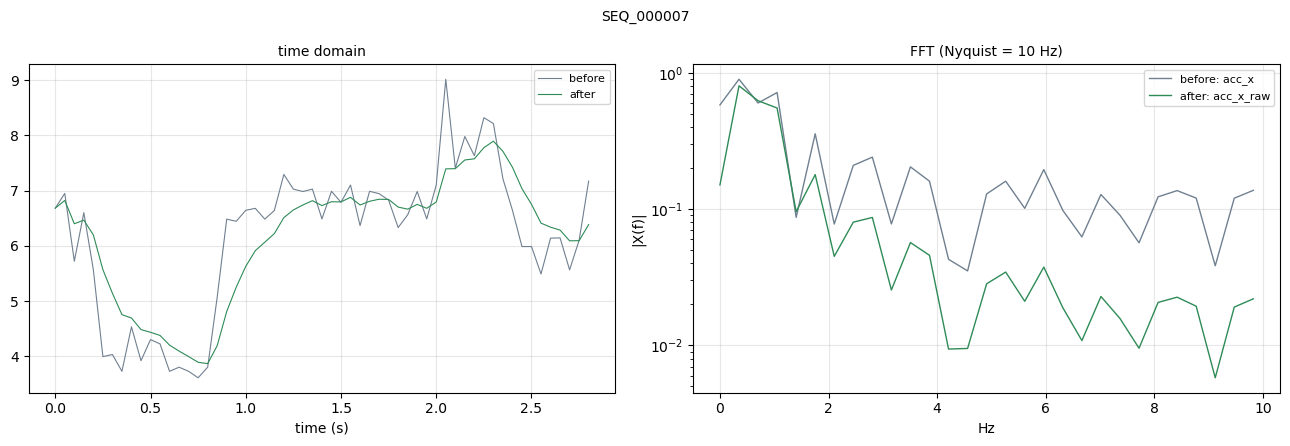

before peak=  0.35 Hz | centroid=  3.29 Hz | power=5.402
after  peak=  0.35 Hz | centroid=  1.71 Hz | power=2.921


In [11]:
params = dict(
    acc_modes='raw|velocity|jerk',
    rotation_modes='quaternion|angular_velocity',
    motion_filter_mode='kalman',
    use_dead_reckoning=False,
    smooth_alpha=0.0,
    window_size=7,
    clip_value=0.0,
)

seq_id = explorer.meta_.index[0]
explorer.update_spectrum(seq_id, '', 'acc_x_raw', 'fft', True, True, **params)

In [12]:
# Raw kalman sweep on one channel
for q in [1e-4, 1e-3, 1e-2]:
    frame = explorer.extract(
        explorer.sequence(seq_id),
        **explorer._params('raw', 'quaternion', 'kalman', False, 0.0, 7, 0.0),
        kalman_process_noise=q,
    )
    print(f'Q={q:g}  acc_x std after filtering = {frame["acc_x_raw"].std():.4f}')

Q=0.0001  acc_x std after filtering = 0.8540
Q=0.001  acc_x std after filtering = 1.1123
Q=0.01  acc_x std after filtering = 1.2633
